# Regression with a Perceptron — Gradient Descent

A guided notebook transcribed and expanded from the Coursera
*Calculus for Machine Learning and Data Science* lecture on training a perceptron with
**gradient descent** (Week 3 — Optimization in Neural Networks and Newton's Method).

This notebook explains:

- the goal: minimize the loss $L$ over the weights $w_1, w_2$ and bias $b$
- deriving the gradients with the **chain rule**
- the four building blocks $\partial L/\partial\hat{y}$, $\partial\hat{y}/\partial w_1$,
  $\partial\hat{y}/\partial w_2$, $\partial\hat{y}/\partial b$
- the assembled gradients and the **gradient-descent update rules**
- a SymPy verification and a full training run that fits the house data

This notebook follows the repository `GUIDELINES.md` template and continues directly from
*Regression with a Perceptron — The Loss Function*.

## 1. The goal and the update rules

We want the weights and bias that make the smallest mistakes — i.e. that **minimize the
loss**. We use **gradient descent**:

$$
w_1 \leftarrow w_1 - \alpha\,\frac{\partial L}{\partial w_1}, \qquad
w_2 \leftarrow w_2 - \alpha\,\frac{\partial L}{\partial w_2}, \qquad
b \leftarrow b - \alpha\,\frac{\partial L}{\partial b},
$$

where $\alpha$ is the learning rate.

> *"You have some starting $w_1, w_2, b$. Calculate these three gradients, update them, and
> you get a better model with smaller loss. Do this for a long time and you end up with
> pretty good weights."*

So we just need the three partial derivatives. The model and loss are

$$
\hat{y} = w_1 x_1 + w_2 x_2 + b, \qquad L = \tfrac12 (y - \hat{y})^2 .
$$

## 2. The chain rule decomposition

$L$ depends on $\hat{y}$, and $\hat{y}$ depends on each parameter. So by the **chain rule**:

$$
\frac{\partial L}{\partial b}  = \frac{\partial L}{\partial \hat{y}}\,\frac{\partial \hat{y}}{\partial b},\qquad
\frac{\partial L}{\partial w_1} = \frac{\partial L}{\partial \hat{y}}\,\frac{\partial \hat{y}}{\partial w_1},\qquad
\frac{\partial L}{\partial w_2} = \frac{\partial L}{\partial \hat{y}}\,\frac{\partial \hat{y}}{\partial w_2}.
$$

> *"Notice $\partial L/\partial\hat{y}$ repeats three times — so we calculate that once,
> plus the three derivatives of $\hat{y}$. It's like breaking the problem into easier
> sub-problems."*

## 3. The four building blocks

**The shared piece** $\dfrac{\partial L}{\partial \hat{y}}$. With $L = \tfrac12 (y-\hat{y})^2$,
the outer derivative gives $(y-\hat{y})$ and the inside $\dfrac{\partial}{\partial\hat{y}}(y-\hat{y}) = -1$:

$$
\frac{\partial L}{\partial \hat{y}} = \tfrac12 \cdot 2 (y-\hat{y})\cdot(-1) = -\,(y - \hat{y}).
$$

**The three easy pieces.** In $\hat{y} = w_1 x_1 + w_2 x_2 + b$, each parameter sees the
rest as a constant:

$$
\frac{\partial \hat{y}}{\partial b} = 1, \qquad
\frac{\partial \hat{y}}{\partial w_1} = x_1, \qquad
\frac{\partial \hat{y}}{\partial w_2} = x_2 .
$$

## 4. Assembling the gradients

Multiplying the shared piece by each easy piece:

$$
\boxed{\;\frac{\partial L}{\partial b} = -(y - \hat{y}), \qquad
\frac{\partial L}{\partial w_1} = -x_1 (y - \hat{y}), \qquad
\frac{\partial L}{\partial w_2} = -x_2 (y - \hat{y}).\;}
$$

Plugging these into gradient descent (the minus signs flip to plus):

$$
w_1 \leftarrow w_1 + \alpha\,x_1 (y - \hat{y}), \qquad
w_2 \leftarrow w_2 + \alpha\,x_2 (y - \hat{y}), \qquad
b \leftarrow b + \alpha\,(y - \hat{y}).
$$

Intuitively: if the prediction is **too low** ($y - \hat{y} > 0$), each weight is nudged
**up** in proportion to its input.

## 5. Verifying the derivatives with SymPy

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

w1, w2, b, x1, x2, y = sp.symbols('w1 w2 b x1 x2 y')
y_hat = w1*x1 + w2*x2 + b
L = sp.Rational(1, 2) * (y - y_hat)**2

print("∂L/∂w1 =", sp.simplify(sp.diff(L, w1)), "   (expected -x1*(y - y_hat))")
print("∂L/∂w2 =", sp.simplify(sp.diff(L, w2)), "   (expected -x2*(y - y_hat))")
print("∂L/∂b  =", sp.simplify(sp.diff(L, b)),  "   (expected -(y - y_hat))")

∂L/∂w1 = x1*(b + w1*x1 + w2*x2 - y)    (expected -x1*(y - y_hat))
∂L/∂w2 = x2*(b + w1*x1 + w2*x2 - y)    (expected -x2*(y - y_hat))
∂L/∂b  = b + w1*x1 + w2*x2 - y    (expected -(y - y_hat))


## 6. Training a perceptron on the house data

We now use these gradients to **train** a perceptron. For a clear plot we use the single
feature *size* with a bias, $\hat{y} = w\cdot\text{size} + b$, and average the per-point
gradients over the dataset. The features and target are standardized so a single learning
rate works well.

In [2]:
size   = np.array([1000, 2000, 3000], dtype=float)
price  = np.array([20000, 30000, 50000], dtype=float)

# standardize
xs = (size - size.mean()) / size.std()
ys = (price - price.mean()) / price.std()

def train_perceptron(x, y, alpha=0.1, epochs=200):
    w, b = 0.0, 0.0
    losses = []
    for _ in range(epochs):
        y_hat = w * x + b
        error = y - y_hat                      # (y - y_hat)
        # gradients averaged over the dataset
        dw = -np.mean(x * error)               # ∂L/∂w = -x(y - y_hat)
        db = -np.mean(error)                   # ∂L/∂b = -(y - y_hat)
        w -= alpha * dw                        # update rules
        b -= alpha * db
        losses.append(0.5 * np.mean(error**2))
    return w, b, losses

w_t, b_t, losses = train_perceptron(xs, ys, alpha=0.3, epochs=200)
print(f"trained (standardized): w = {w_t:.4f}, b = {b_t:.4f}")

# compare with the exact least-squares slope/intercept on standardized data
w_exact, b_exact = np.polyfit(xs, ys, 1)
print(f"exact least squares   : w = {w_exact:.4f}, b = {b_exact:.4f}")

trained (standardized): w = 0.9820, b = -0.0000
exact least squares   : w = 0.9820, b = -0.0000


### The loss decreasing and the resulting fit

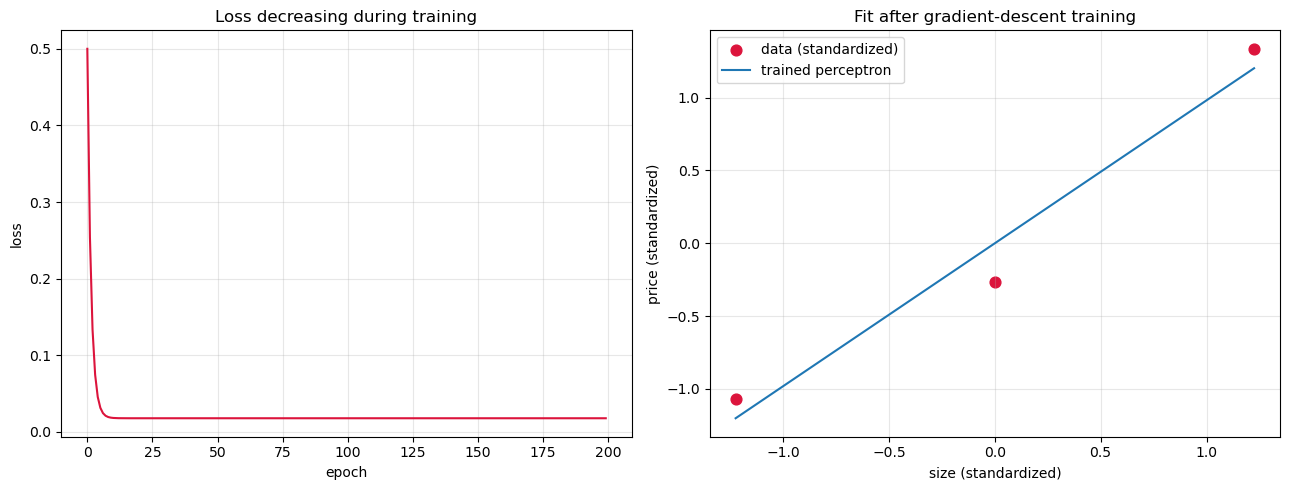

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(losses, color="crimson")
axes[0].set_title("Loss decreasing during training")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(xs, ys, s=60, color="crimson", label="data (standardized)")
line_x = np.linspace(xs.min(), xs.max(), 100)
axes[1].plot(line_x, w_t*line_x + b_t, label="trained perceptron")
axes[1].set_title("Fit after gradient-descent training")
axes[1].set_xlabel("size (standardized)"); axes[1].set_ylabel("price (standardized)")
axes[1].grid(True, alpha=0.3); axes[1].legend()

plt.tight_layout()
plt.show()

### Two features

The same update rules extend to two features. Here we train $w_1, w_2, b$ on
*size* and *rooms* (per the earlier lecture, rooms = 2, 4, 7).

In [4]:
rooms = np.array([2, 4, 7], dtype=float)
X1 = (size - size.mean()) / size.std()
X2 = (rooms - rooms.mean()) / rooms.std()
Y  = (price - price.mean()) / price.std()

w1_, w2_, b_ = 0.0, 0.0, 0.0
alpha = 0.2
for _ in range(500):
    y_hat = w1_*X1 + w2_*X2 + b_
    err = Y - y_hat
    w1_ += alpha * np.mean(X1 * err)     # w1 += α x1 (y - y_hat)
    w2_ += alpha * np.mean(X2 * err)     # w2 += α x2 (y - y_hat)
    b_  += alpha * np.mean(err)          # b  += α (y - y_hat)

print(f"trained weights: w1 = {w1_:.4f}, w2 = {w2_:.4f}, b = {b_:.4f}")
print(f"final loss = {0.5*np.mean((Y - (w1_*X1 + w2_*X2 + b_))**2):.6f}")

trained weights: w1 = -0.0600, w2 = 1.0529, b = -0.0000
final loss = 0.002334


## 7. Exercises

### Basic
1. Write the gradient-descent update rules for $w_1, w_2, b$.
2. What is $\partial L/\partial \hat{y}$ for $L = \tfrac12(y-\hat{y})^2$?

### Intermediate
3. Use the chain rule to derive $\partial L/\partial w_1$ and confirm it equals
   $-x_1(y-\hat{y})$.
4. In the update $w_1 \leftarrow w_1 + \alpha x_1 (y - \hat{y})$, what happens to $w_1$ when
   the prediction is too high ($y < \hat{y}$)?

### Advanced
5. Train the single-feature perceptron with a smaller learning rate (e.g. $\alpha=0.05$).
   How does the loss curve change?
6. Show that averaging the per-point gradients over $n$ points gives
   $\partial L/\partial w = -\tfrac1n\sum_i x_i (y_i - \hat{y}_i)$, and explain why this is
   the gradient of the *mean* loss.

## 8. Solutions / Checks

In [5]:
# 3. chain-rule check
print("3. ∂L/∂w1 =", sp.simplify(sp.diff(L, w1)), " = -x1*(y - y_hat) ✓")

# 5. smaller learning rate -> slower descent (compare loss early, at epoch 20)
_, _, losses_slow = train_perceptron(xs, ys, alpha=0.05, epochs=200)
print(f"5. loss at epoch 20:  α=0.05 -> {losses_slow[19]:.5f}   vs   α=0.3 -> {losses[19]:.5f}")
print(f"   both fully converge by epoch 200 (final loss ≈ {losses[-1]:.5f}); "
      "the smaller α just takes more epochs to get there.")

print("4. If y < y_hat then (y - y_hat) < 0, so w1 decreases — the model lowers its "
      "prediction.")
print("6. The mean loss is (1/n)Σ L_i; differentiating term by term gives "
      "(1/n)Σ ∂L_i/∂w = -(1/n)Σ x_i (y_i - ŷ_i).")

3. ∂L/∂w1 = x1*(b + w1*x1 + w2*x2 - y)  = -x1*(y - y_hat) ✓
5. loss at epoch 20:  α=0.05 -> 0.08651   vs   α=0.3 -> 0.01786
   both fully converge by epoch 200 (final loss ≈ 0.01786); the smaller α just takes more epochs to get there.
4. If y < y_hat then (y - y_hat) < 0, so w1 decreases — the model lowers its prediction.
6. The mean loss is (1/n)Σ L_i; differentiating term by term gives (1/n)Σ ∂L_i/∂w = -(1/n)Σ x_i (y_i - ŷ_i).


## 9. Conclusion

- Training a perceptron = minimizing the loss with **gradient descent** over $w_1, w_2, b$.
- The gradients come from the **chain rule**, reusing the shared factor
  $\partial L/\partial \hat{y} = -(y-\hat{y})$:

$$
\frac{\partial L}{\partial w_i} = -x_i (y - \hat{y}), \qquad
\frac{\partial L}{\partial b} = -(y - \hat{y}).
$$

- The update rules are $w_i \leftarrow w_i + \alpha\,x_i (y - \hat{y})$ and
  $b \leftarrow b + \alpha\,(y - \hat{y})$.
- Iterating many times yields low loss and a good model — this is exactly how a single
  neuron learns, and the same chain-rule idea (backpropagation) trains full neural
  networks.

## Appendix — Source transcript

Transcribed with OpenAI Whisper (`small.en`) from a locally downloaded video
(`~/Downloads/opt_nns_3.mp4`), the Coursera *Calculus for Machine Learning and Data
Science* (Week 3) lecture on **gradient descent for a perceptron**. Key spoken points,
lightly cleaned:

> We want the best $w_1, w_2, b$ that minimize the loss, found with gradient descent:
> update each parameter as itself minus $\alpha$ times the corresponding gradient. To get
> the gradients, use the chain rule: $L$ depends on $\hat{y}$, and $\hat{y}$ depends on each
> parameter, so $\partial L/\partial b = (\partial L/\partial\hat{y})(\partial\hat{y}/\partial b)$,
> and likewise for $w_1, w_2$. The shared factor $\partial L/\partial\hat{y}$ — from
> $\tfrac12(y-\hat{y})^2$ — is $-(y-\hat{y})$. The easy factors are
> $\partial\hat{y}/\partial b = 1$, $\partial\hat{y}/\partial w_1 = x_1$,
> $\partial\hat{y}/\partial w_2 = x_2$. So $\partial L/\partial b = -(y-\hat{y})$,
> $\partial L/\partial w_1 = -x_1(y-\hat{y})$, $\partial L/\partial w_2 = -x_2(y-\hat{y})$,
> and the gradient-descent steps update $b$, $w_1$, $w_2$ accordingly. Repeating many times
> gives weights with very small error — a good model.